avaliação da logistica

===== MÉTRICAS =====
Accuracy: 0.8095
Precision: 0.6966
Recall: 0.2457
F1 Score: 0.3632
ROC AUC: 0.7100
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.70      0.25      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.76      0.61      0.63      6000
weighted avg       0.79      0.81      0.77      6000

Matriz de Confusão
[[4531  142]
 [1001  326]]


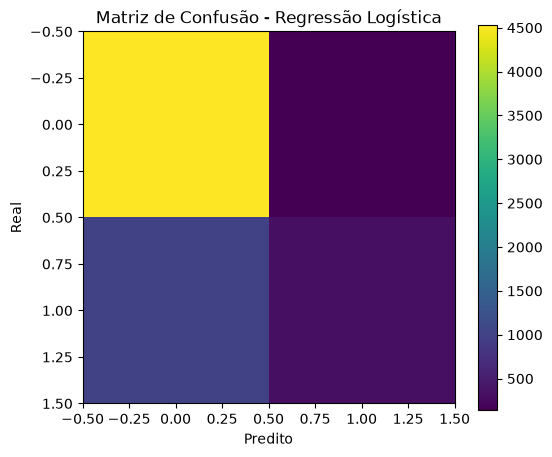

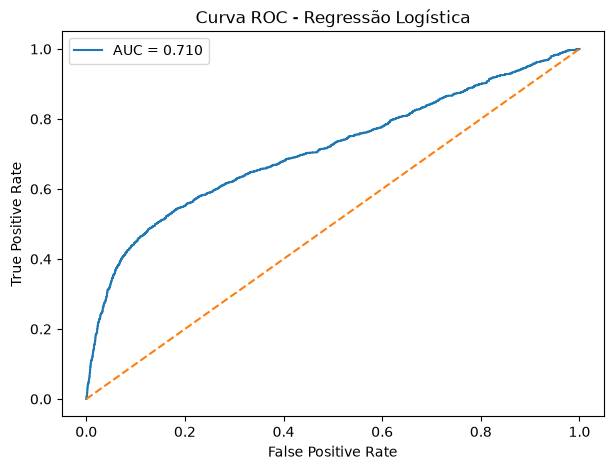

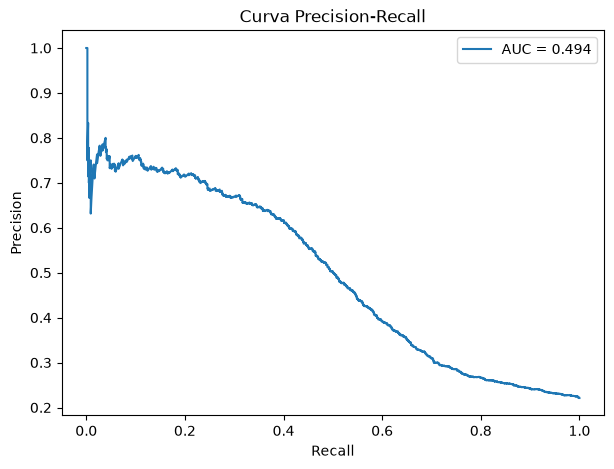

    threshold  precision    recall        f1
0        0.10   0.244762  0.889224  0.383865
1        0.15   0.269120  0.776940  0.399767
2        0.20   0.319454  0.688018  0.436320
3        0.25   0.440168  0.551620  0.489632
4        0.30   0.551724  0.458176  0.500618
5        0.35   0.597627  0.417483  0.491571
6        0.40   0.629213  0.379804  0.473684
7        0.45   0.659341  0.316503  0.427699
8        0.50   0.696581  0.245667  0.363231
9        0.55   0.727545  0.183120  0.292595
10       0.60   0.734234  0.122833  0.210458
11       0.65   0.748031  0.071590  0.130674
12       0.70   0.741573  0.049736  0.093220
13       0.75   0.783333  0.035418  0.067772
14       0.80   0.767442  0.024868  0.048175
15       0.85   0.650000  0.009797  0.019302


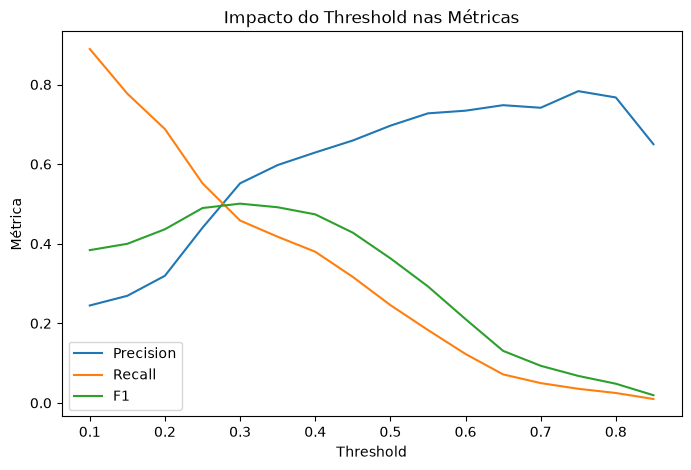

In [5]:
# ============================================================
# CREDIT DEFAULT API
# 06_model_evaluation.py
# Avaliação da Regressão Logística
# ============================================================


# ============================================================
# 1. IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

# ============================================================
# 2. CARREGAR MODELO
# ============================================================

model = joblib.load(
    "../models/logistic_regression_pipeline.pkl"
)

# ============================================================
# 3. CARREGAR DADOS
# ============================================================

df = pd.read_excel(
    "C:/Users/T-Gamer/Desktop/igor/credit-default-api/data/raw/default_of_credit_card_clients.xls",
    header=1)

# ============================================================
# 4. SEPARAÇÃO X E Y
# ============================================================

X = df.drop(
    columns=[
        "ID",
        "default payment next month"
    ]
)

y = df[
    "default payment next month"
]

# ============================================================
# 5. DIVISÃO TREINO / TESTE
# ============================================================

_, X_test, _, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ============================================================
# 6. PREVISÕES
# ============================================================

y_prob = model.predict_proba(
    X_test
)[:,1]

# threshold padrão

threshold = 0.5

y_pred = (
    y_prob >= threshold
).astype(int)

# ============================================================
# 7. MÉTRICAS
# ============================================================

print("===== MÉTRICAS =====")

print(
    f"Accuracy: {accuracy_score(y_test,y_pred):.4f}"
)

print(
    f"Precision: {precision_score(y_test,y_pred):.4f}"
)

print(
    f"Recall: {recall_score(y_test,y_pred):.4f}"
)

print(
    f"F1 Score: {f1_score(y_test,y_pred):.4f}"
)

print(
    f"ROC AUC: {roc_auc_score(y_test,y_prob):.4f}"
)

# ============================================================
# 8. CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        y_pred
    )
)

# ============================================================
# 9. MATRIZ DE CONFUSÃO
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Matriz de Confusão")
print(cm)

plt.figure(figsize=(6,5))
plt.imshow(
    cm
)

plt.title(
    "Matriz de Confusão - Regressão Logística"
)

plt.xlabel(
    "Predito"
)

plt.ylabel(
    "Real"
)

plt.colorbar()
plt.show()

# ============================================================
# 10. CURVA ROC
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Curva ROC - Regressão Logística"
)

plt.legend()
plt.show()

# ============================================================
# 11. CURVA PRECISION-RECALL
# ============================================================

precision, recall, thresholds_pr = precision_recall_curve(
    y_test,
    y_prob
)

pr_auc = auc(
    recall,
    precision
)

plt.figure(figsize=(7,5))

plt.plot(
    recall,
    precision,
    label=f"AUC = {pr_auc:.3f}"
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Curva Precision-Recall"
)

plt.legend()
plt.show()

# ============================================================
# 12. ANÁLISE DE THRESHOLD
# ============================================================
thresholds = np.arange(
    0.1,
    0.9,
    0.05
)

results = []

for threshold in thresholds:
    y_pred_threshold = (
        y_prob >= threshold
    ).astype(int)

    results.append(
        {
            "threshold": threshold,

            "precision":
            precision_score(
                y_test,
                y_pred_threshold
            ),

            "recall":
            recall_score(
                y_test,
                y_pred_threshold
            ),

            "f1":
            f1_score(
                y_test,
                y_pred_threshold
            )
        }
    )

threshold_df = pd.DataFrame(
    results
)

print(threshold_df)
# ============================================================
# 13. GRÁFICO THRESHOLD
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    label="F1"
)

plt.xlabel(
    "Threshold"
)

plt.ylabel(
    "Métrica"
)

plt.title(
    "Impacto do Threshold nas Métricas"
)

plt.legend()
plt.show()

In [ ]:
# ============================================================
# CREDIT DEFAULT API
# 04_modeling.ipynb
# Regressão Logística + Grid Search
# ============================================================

# ============================================================
# 1. IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import joblib
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 2. LEITURA DOS DADOS
# ============================================================

df = pd.read_excel(
    "C:/Users/T-Gamer/Desktop/igor/credit-default-api/data/raw/default_of_credit_card_clients.xls",
    header=1)
    
print(df.shape)

# ============================================================
# 3. SEPARAÇÃO X E Y
# ============================================================

X = df.drop(
    columns=[
        "ID",
        "default payment next month"
    ]
)

y = df["default payment next month"]

# ============================================================
# 4. TRAIN / TEST
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

# ============================================================
# 5. VARIÁVEIS
# ============================================================

categorical_features = [
    "SEX",
    "EDUCATION",
    "MARRIAGE"
]

numeric_features = [
    col
    for col in X.columns
    if col not in categorical_features
]

print("Numéricas:", len(numeric_features))
print("Categóricas:", len(categorical_features))

# ============================================================
# 6. PRÉ-PROCESSAMENTO
# ============================================================

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

# ============================================================
# 7. PIPELINE
# ============================================================

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                random_state=42,
                max_iter=1000
            )
        )
    ]
)

# ============================================================
# 8. HIPERPARÂMETROS
# ============================================================

param_grid = {

    "classifier__C":[
        0.01,
        0.1,
        1,
        10,
        100
    ],

    "classifier__penalty":[
        "l1",
        "l2"
    ],

    "classifier__solver":[
        "liblinear"
    ],

    "classifier__class_weight":[
        None,
        "balanced"
    ]

}

# ============================================================
# 9. GRID SEARCH
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(

    estimator=pipeline,

    param_grid=param_grid,

    scoring="roc_auc",

    cv=cv,

    n_jobs=-1,

    verbose=2,

    refit=True

)

print("Treinando modelo...")

grid_search.fit(
    X_train,
    y_train
)

# ============================================================
# 10. MELHOR MODELO
# ============================================================

best_model = grid_search.best_estimator_

print("="*60)

print("MELHORES PARÂMETROS")

print("="*60)

print(grid_search.best_params_)

print()

print("Melhor ROC AUC (CV):")

print(grid_search.best_score_)

# ============================================================
# 11. PREDIÇÕES
# ============================================================

y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:,1]

# ============================================================
# 12. MÉTRICAS
# ============================================================

print("\n===== RESULTADOS =====")

print(f"Accuracy : {accuracy_score(y_test,y_pred):.4f}")

print(f"Precision: {precision_score(y_test,y_pred):.4f}")

print(f"Recall   : {recall_score(y_test,y_pred):.4f}")

print(f"F1 Score : {f1_score(y_test,y_pred):.4f}")

print(f"ROC AUC  : {roc_auc_score(y_test,y_prob):.4f}")

print()

print(classification_report(
    y_test,
    y_pred
))

print(confusion_matrix(
    y_test,
    y_pred
))

# ============================================================
# 13. SALVAR MODELO
# ============================================================

joblib.dump(
    best_model,
    "../models/logistic_regression_tuned_pipeline.pkl"
)

print()

print("Modelo otimizado salvo com sucesso!")

(30000, 25)
(24000, 23)
(6000, 23)
Numéricas: 20
Categóricas: 3
Treinando modelo...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
MELHORES PARÂMETROS
{'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}

Melhor ROC AUC (CV):
0.7274981161754775

===== RESULTADOS =====
Accuracy : 0.6780
Precision: 0.3675
Recall   : 0.6323
F1 Score : 0.4648
ROC AUC  : 0.7105

              precision    recall  f1-score   support

           0       0.87      0.69      0.77      4673
           1       0.37      0.63      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000

[[3229 1444]
 [ 488  839]]

Modelo otimizado salvo com sucesso!
